# Temas Tratados en el Trabajo Práctico 5

* Comportamiento y operaciones bajo incertidumbre.

* Teorema de Bayes.

* Representación de la información incierta en Redes Bayesianas.

* Inferencia por enumeración.

* Redes de Markov y matrices de transición.

* Tiempo esperado y probabilidad de absorción.


## Ejercicios Teóricos

1. ¿Cuáles son los tres axiomas de Kolmogorov?

### Resolución

Los **axiomas de Kolmogórov** establecen las condiciones fundamentales que debe cumplir una función de probabilidad.

Sea $\Omega$ el espacio muestral de un experimento aleatorio y sea $A$ un evento, es decir, un subconjunto de $\Omega$. Una función de probabilidad $P$ debe cumplir los siguientes tres axiomas:

#### 1. No negatividad

La probabilidad de cualquier evento debe ser mayor o igual que cero:

$$
P(A)\geq 0
$$

Una probabilidad negativa no tendría interpretación válida como proporción o grado de creencia.

#### 2. Normalización

La probabilidad del espacio muestral completo es igual a uno:

$$
P(\Omega)=1
$$

El espacio muestral contiene todos los resultados posibles, por lo que existe certeza de que ocurrirá alguno de ellos.

#### 3. Aditividad numerable

Si $A_1,A_2,\ldots$ son eventos mutuamente excluyentes, es decir:

$$
A_i\cap A_j=\varnothing
\qquad \text{para } i\neq j
$$

entonces la probabilidad de su unión es igual a la suma de sus probabilidades:

$$
P\left(\bigcup_{i=1}^{\infty}A_i\right)
=
\sum_{i=1}^{\infty}P(A_i)
$$

Por ejemplo, al lanzar un dado equilibrado, los eventos “obtener 1” y “obtener 2” son mutuamente excluyentes. Por lo tanto:

$$
P(\{1,2\})=P(\{1\})+P(\{2\})
=\frac{1}{6}+\frac{1}{6}
=\frac{1}{3}
$$

A partir de estos axiomas se obtienen propiedades importantes como:

$$
P(\varnothing)=0
$$

$$
P(A^c)=1-P(A)
$$

$$
0\leq P(A)\leq1
$$

Por lo tanto, los axiomas de Kolmogórov garantizan que las probabilidades asignadas a los eventos sean matemáticamente coherentes.


2. Una fábrica de clavos dispone de 2 máquinas que elaboran el 30% y 70% de los clavos que producen respectivamente. El porcentaje de clavos defectuosos de cada máquina es del 2% y 3%, respectivamente. Si se selecciona al azar un clavo de la producción y este fue defectuoso, ¿cuál es la probabilidad de que haya sido fabricado por la máquina?

### Resolución

Definimos los siguientes eventos:

- $M_1$: el clavo fue fabricado por la máquina 1.
- $M_2$: el clavo fue fabricado por la máquina 2.
- $D$: el clavo seleccionado es defectuoso.

Las probabilidades de producción de cada máquina son:

$$
P(M_1)=0.30
$$

$$
P(M_2)=0.70
$$

Las probabilidades condicionales de producir un clavo defectuoso son:

$$
P(D\mid M_1)=0.02
$$

$$
P(D\mid M_2)=0.03
$$

Primero calculamos la probabilidad total de seleccionar un clavo defectuoso mediante la regla de probabilidad total:

$$
P(D)
=
P(D\mid M_1)P(M_1)
+
P(D\mid M_2)P(M_2)
$$

Reemplazando:

$$
P(D)
=
0.02(0.30)+0.03(0.70)
$$

$$
P(D)=0.006+0.021=0.027
$$

Por lo tanto, la probabilidad general de seleccionar un clavo defectuoso es:

$$
\boxed{P(D)=0.027=2.7\%}
$$

Aplicando el teorema de Bayes para la máquina 1:

$$
P(M_1\mid D)
=
\frac{P(D\mid M_1)P(M_1)}
{P(D)}
$$

$$
P(M_1\mid D)
=
\frac{0.02(0.30)}{0.027}
=
\frac{0.006}{0.027}
\approx0.2222
$$

Por lo tanto:

$$
\boxed{P(M_1\mid D)\approx22.22\%}
$$

Para la máquina 2:

$$
P(M_2\mid D)
=
\frac{P(D\mid M_2)P(M_2)}
{P(D)}
$$

$$
P(M_2\mid D)
=
\frac{0.03(0.70)}{0.027}
=
\frac{0.021}{0.027}
\approx0.7778
$$

Por lo tanto:

$$
\boxed{P(M_2\mid D)\approx77.78\%}
$$

Se verifica que:

$$
P(M_1\mid D)+P(M_2\mid D)=1
$$

En conclusión, si el clavo seleccionado es defectuoso, existe aproximadamente un **22.22% de probabilidad de que haya sido fabricado por la máquina 1** y un **77.78% de probabilidad de que haya sido fabricado por la máquina 2**.

3. La probabilidad de que un motor que sale de una fábrica con una *avería eléctrica* es de $10^{-3}$, y la probabilidad de que salga con una *avería mecánica* es de $10^{-5}$. Si existe un tipo de avería no se producen averías del otro tipo.
<br><br>Si el motor presenta *temperatura elevada* se enciende un *piloto luminoso* el 95% de las veces, cuando la *temperatura es reducida* el *piloto luminoso* se enciende el 99% de las veces, y a veces cuando la *temperatura se encuentra en un rango normal* el *piloto luminoso* se enciende erróneamente en un caso por millón.
<br><br>Cuando *no hay averías*, la *temperatura se eleva* en el 17% de los casos y es *reducida* el 5% de las veces. Si hay una *avería eléctrica*, la *temperatura se eleva* en el 90% de los casos y es *reducida* en el 1% de los casos. Finalmente cuando la *avería es mecánica*, la *temperatura está elevada* el 10% de los casos y *reducida* el 40% de las veces.
<br><br>Construya una Red Bayesiana y utilice inferencia por enumeración para calcular:

        3.1 La probabilidad de que el motor tenga una avería mecánica si se enciende el piloto.

        3.2 La probabilidad de que el motor tenga una avería mecánica si se enciende el piloto y la temperatura es elevada.

### Resolución

#### 1. Definición de los eventos

Para representar el problema se definen los siguientes eventos:

- $AM$: el motor presenta una avería mecánica.
- $AE$: el motor presenta una avería eléctrica.
- $TE$: la temperatura del motor es elevada.
- $TR$: la temperatura del motor es reducida.
- $TN$: la temperatura del motor se encuentra en el rango normal.
- $P$: el piloto luminoso se enciende.

Las probabilidades iniciales de las averías son:

$$
P(AM)=10^{-5}=0.00001
$$

$$
P(AE)=10^{-3}=0.001
$$

La consigna indica que las averías mecánica y eléctrica son mutuamente excluyentes. Por lo tanto, no pueden ocurrir simultáneamente:

$$
P(AM\cap AE)=0
$$

La probabilidad de que no exista ninguna avería es:

$$
P(\neg AM,\neg AE)
=
1-P(AM)-P(AE)
$$

$$
P(\neg AM,\neg AE)
=
1-0.00001-0.001
$$

$$
\boxed{
P(\neg AM,\neg AE)=0.99899
}
$$

#### 2. Probabilidades de la temperatura

La temperatura puede encontrarse en uno de tres estados mutuamente excluyentes:

$$
T\in\{TE,TR,TN\}
$$

Las probabilidades condicionales son:

| Condición del motor | Temperatura elevada | Temperatura reducida | Temperatura normal |
|---|---:|---:|---:|
| Avería mecánica $AM$ | $P(TE\mid AM)=0.10$ | $P(TR\mid AM)=0.40$ | $P(TN\mid AM)=0.50$ |
| Avería eléctrica $AE$ | $P(TE\mid AE)=0.90$ | $P(TR\mid AE)=0.01$ | $P(TN\mid AE)=0.09$ |
| Sin averías $\neg AM,\neg AE$ | $0.17$ | $0.05$ | $0.78$ |

Las probabilidades de temperatura normal se obtienen por complemento. Por ejemplo:

$$
P(TN\mid AM)
=
1-P(TE\mid AM)-P(TR\mid AM)
$$

$$
P(TN\mid AM)=1-0.10-0.40=0.50
$$

#### 3. Probabilidades del piloto

La probabilidad de que se encienda el piloto depende del estado de la temperatura:

$$
P(P\mid TE)=0.95
$$

$$
P(P\mid TR)=0.99
$$

$$
P(P\mid TN)=10^{-6}
$$

El último valor representa un falso positivo: el piloto se enciende aunque la temperatura sea normal.

#### 4. Orden del árbol de enumeración

Como trabajamos en clase con el profesor, el árbol de enumeración sigue el orden:

$$
AM\longrightarrow AE\longrightarrow TE\longrightarrow TR\longrightarrow P
$$

Primero se determina si existe una avería mecánica. Luego se comprueba la avería eléctrica, después la temperatura y, finalmente, el encendido del piloto.

Si $AM$ es verdadera, la rama $AE$ se trunca porque las dos averías no pueden existir simultáneamente:

$$
P(AE\mid AM)=0
$$

$$
P(\neg AE\mid AM)=1
$$

En la rama $\neg AM$, todavía puede existir o no una avería eléctrica:

$$
P(AE\mid\neg AM)
=
\frac{P(AE)}{P(\neg AM)}
=
\frac{0.001}{0.99999}
\approx0.00100001
$$

$$
P(\neg AE\mid\neg AM)
=
\frac{0.99899}{0.99999}
\approx0.99899999
$$

Después se evalúan los estados de temperatura. Si $TE$ es verdadera, entonces $TR$ necesariamente es falsa. Si $TE$ es falsa, se comprueba si la temperatura es reducida o normal.

Por ejemplo, dentro de la rama $AM$:

$$
P(TR\mid\neg TE,AM)
=
\frac{P(TR\mid AM)}{P(\neg TE\mid AM)}
=
\frac{0.40}{0.90}
=
\frac{4}{9}
$$

Esto garantiza que la probabilidad conjunta de llegar a temperatura reducida siga siendo:

$$
P(\neg TE\mid AM)
P(TR\mid\neg TE,AM)
=
0.90\left(\frac{4}{9}\right)
=
0.40
$$

En los cálculos siguientes se sumarán las contribuciones de los tres estados posibles de temperatura: elevada, reducida y normal.

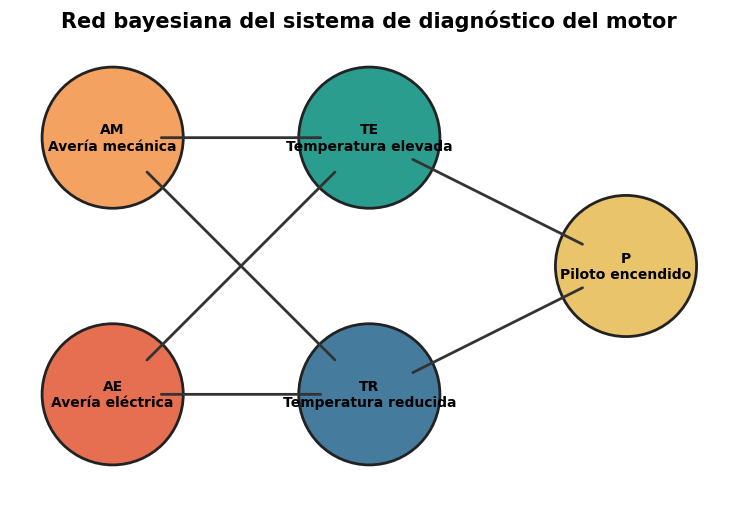

In [33]:
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

fig, ax = plt.subplots(figsize=(11, 6))

# Posiciones similares a las del pizarrón.
posiciones = {
    "AM": (0, 2),
    "AE": (0, 0),
    "TE": (2, 2),
    "TR": (2, 0),
    "P":  (4, 1)
}

etiquetas = {
    "AM": "AM\nAvería mecánica",
    "AE": "AE\nAvería eléctrica",
    "TE": "TE\nTemperatura elevada",
    "TR": "TR\nTemperatura reducida",
    "P":  "P\nPiloto encendido"
}

colores = {"AM": "#f4a261", "AE": "#e76f51", "TE": "#2a9d8f", "TR": "#457b9d", "P":  "#e9c46a"}

# Relaciones de dependencia.
conexiones = [
    ("AM", "TE"),
    ("AM", "TR"),
    ("AE", "TE"),
    ("AE", "TR"),
    ("TE", "P"),
    ("TR", "P")
]

# Dibujamos las flechas.
for origen, destino in conexiones:
    ax.annotate("", xy=posiciones[destino], xytext=posiciones[origen], 
                arrowprops={"arrowstyle": "-","linewidth": 2,"color": "#333333","shrinkA": 35,"shrinkB": 35} )

# Dibujamos los nodos.
for nodo, (x, y) in posiciones.items():
    circulo = Circle( (x, y), radius=0.55, facecolor=colores[nodo], edgecolor="#222222", linewidth=2 )

    ax.add_patch(circulo)

    ax.text(x, y, etiquetas[nodo], ha="center", va="center", fontsize=10,fontweight="bold")

ax.set_title( "Red bayesiana del sistema de diagnóstico del motor", fontsize=15, fontweight="bold")

ax.set_xlim(-0.8, 4.8)
ax.set_ylim(-0.8, 2.8)
ax.set_aspect("equal")
ax.axis("off")

plt.show()

#### 3.1 Probabilidad de avería mecánica dado que se enciende el piloto

Se desea calcular:

$$
P(AM\mid P)
$$

Aplicando el teorema de Bayes:

$$
P(AM\mid P)
=
\frac{P(P\mid AM)P(AM)}
{P(P)}
$$

Como los dos casos posibles son $AM$ y $\neg AM$, la probabilidad total del piloto es:

$$
P(P)
=
P(P\mid AM)P(AM)
+
P(P\mid\neg AM)P(\neg AM)
$$

Por lo tanto:

$$
P(AM\mid P)
=
\frac{P(P\mid AM)P(AM)}
{P(P\mid AM)P(AM)+P(P\mid\neg AM)P(\neg AM)}
$$

Como trabajamos en clase con el profesor, calculamos por separado los dos árboles:

1. $P(P\mid AM)$.
2. $P(P\mid\neg AM)$.

---

##### A. Cálculo de $P(P\mid AM)$

Si hay una avería mecánica, la rama correspondiente a una avería eléctrica se trunca:

$$
P(AE\mid AM)=0
$$

$$
P(\neg AE\mid AM)=1
$$

El piloto puede encenderse por tres caminos:

1. La temperatura es elevada y el piloto se enciende.
2. La temperatura es reducida y el piloto se enciende.
3. La temperatura es normal y se produce un falso positivo.

Por la regla de probabilidad total:

$$
\begin{aligned}
P(P\mid AM)
={}&P(TE\mid AM)P(P\mid TE)\\
&+P(TR\mid AM)P(P\mid TR)\\
&+P(TN\mid AM)P(P\mid TN)
\end{aligned}
$$

Reemplazando:

$$
P(P\mid AM)
=
0.10(0.95)
+
0.40(0.99)
+
0.50(10^{-6})
$$

$$
P(P\mid AM)
=
0.095+0.396+0.0000005
$$

$$
\boxed{
P(P\mid AM)=0.4910005
}
$$

Esto significa que, si el motor presenta una avería mecánica, el piloto se enciende aproximadamente el $49.10\%$ de las veces.

---

##### B. Cálculo de $P(P\mid\neg AM)$

Si no existe una avería mecánica, todavía hay dos posibilidades:

- que exista una avería eléctrica;
- que no exista ninguna avería.

Primero calculamos la probabilidad del piloto cuando existe una avería eléctrica:

$$
\begin{aligned}
P(P\mid AE)
={}&P(TE\mid AE)P(P\mid TE)\\
&+P(TR\mid AE)P(P\mid TR)\\
&+P(TN\mid AE)P(P\mid TN)
\end{aligned}
$$

$$
P(P\mid AE)
=
0.90(0.95)+0.01(0.99)+0.09(10^{-6})
$$

$$
\boxed{
P(P\mid AE)=0.86490009
}
$$

Ahora calculamos la probabilidad del piloto cuando no existe ninguna avería:

$$
\begin{aligned}
P(P\mid\neg AM,\neg AE)
={}&0.17(0.95)\\
&+0.05(0.99)\\
&+0.78(10^{-6})
\end{aligned}
$$

$$
\boxed{
P(P\mid\neg AM,\neg AE)=0.21100078
}
$$

Combinamos los dos casos posibles dentro de la rama $\neg AM$:

$$
\begin{aligned}
P(P\mid\neg AM)
={}&P(AE\mid\neg AM)P(P\mid AE)\\
&+P(\neg AE\mid\neg AM)
P(P\mid\neg AM,\neg AE)
\end{aligned}
$$

Reemplazando:

$$
\begin{aligned}
P(P\mid\neg AM)
={}&0.00100001(0.86490009)\\
&+0.99899999(0.21100078)
\end{aligned}
$$

$$
\boxed{
P(P\mid\neg AM)\approx0.21165469
}
$$

---

##### C. Aplicación del teorema de Bayes

Sabemos que:

$$
P(AM)=0.00001
$$

$$
P(\neg AM)=1-0.00001=0.99999
$$

Entonces:

$$
P(AM\mid P)
=
\frac{0.4910005(0.00001)}
{0.4910005(0.00001)+0.21165469(0.99999)}
$$

El numerador es:

$$
0.4910005(0.00001)
=
4.910005\times10^{-6}
$$

El denominador es la probabilidad total de encendido del piloto:

$$
P(P)\approx0.21165748
$$

Por lo tanto:

$$
P(AM\mid P)
\approx
\frac{4.910005\times10^{-6}}
{0.21165748}
$$

$$
P(AM\mid P)
\approx2.31979\times10^{-5}
$$

En porcentaje:

$$
\boxed{
P(AM\mid P)\approx0.00232\%
}
$$

Aunque el piloto se encienda, la probabilidad de avería mecánica continúa siendo muy pequeña. Esto se debe a que la avería mecánica es extremadamente poco frecuente y el piloto también puede encenderse sin que exista esa avería.

In [34]:
#PROGRAMA AUXILIAR ARBOLES DE ENUM

import matplotlib.pyplot as plt

plt.close("all")


def dibujar_arbol(ax, nodos, conexiones, titulo, resultado):
    """
    Dibuja un árbol de enumeración.

    nodos:
        diccionario con:
        nombre: (x, y, texto, color)

    conexiones:
        lista con:
        (origen, destino, etiqueta, estilo, color)
    """

    # Primero dibujamos las conexiones.
    for origen, destino, etiqueta, estilo, color in conexiones:
        x1, y1 = nodos[origen][0], nodos[origen][1]
        x2, y2 = nodos[destino][0], nodos[destino][1]

        ax.annotate(
            "",
            xy=(x2, y2),
            xytext=(x1, y1),
            arrowprops={
                "arrowstyle": "->",
                "linewidth": 1.8,
                "linestyle": estilo,
                "color": color,
                "shrinkA": 20,
                "shrinkB": 20
            }
        )

        # Posición de la etiqueta de la conexión.
        xm = (x1 + x2) / 2
        ym = (y1 + y2) / 2

        ax.text(
            xm,
            ym + 0.08,
            etiqueta,
            ha="center",
            va="center",
            fontsize=8,
            bbox={
                "boxstyle": "round,pad=0.2",
                "facecolor": "white",
                "edgecolor": "none",
                "alpha": 0.85
            }
        )

    # Dibujamos los nodos.
    for nombre, (x, y, texto, color) in nodos.items():
        ax.text(
            x,
            y,
            texto,
            ha="center",
            va="center",
            fontsize=10,
            fontweight="bold",
            bbox={
                "boxstyle": "circle,pad=0.45",
                "facecolor": color,
                "edgecolor": "#222222",
                "linewidth": 1.8
            }
        )

    ax.set_title(
        titulo,
        fontsize=14,
        fontweight="bold",
        pad=15
    )

    ax.text(
        0.5,
        -0.02,
        resultado,
        transform=ax.transAxes,
        ha="center",
        va="top",
        fontsize=12,
        fontweight="bold",
        color="#264653"
    )

    valores_x = [datos[0] for datos in nodos.values()]
    valores_y = [datos[1] for datos in nodos.values()]

    ax.set_xlim(min(valores_x) - 1, max(valores_x) + 1)
    ax.set_ylim(min(valores_y) - 0.8, max(valores_y) + 0.7)

    ax.axis("off")

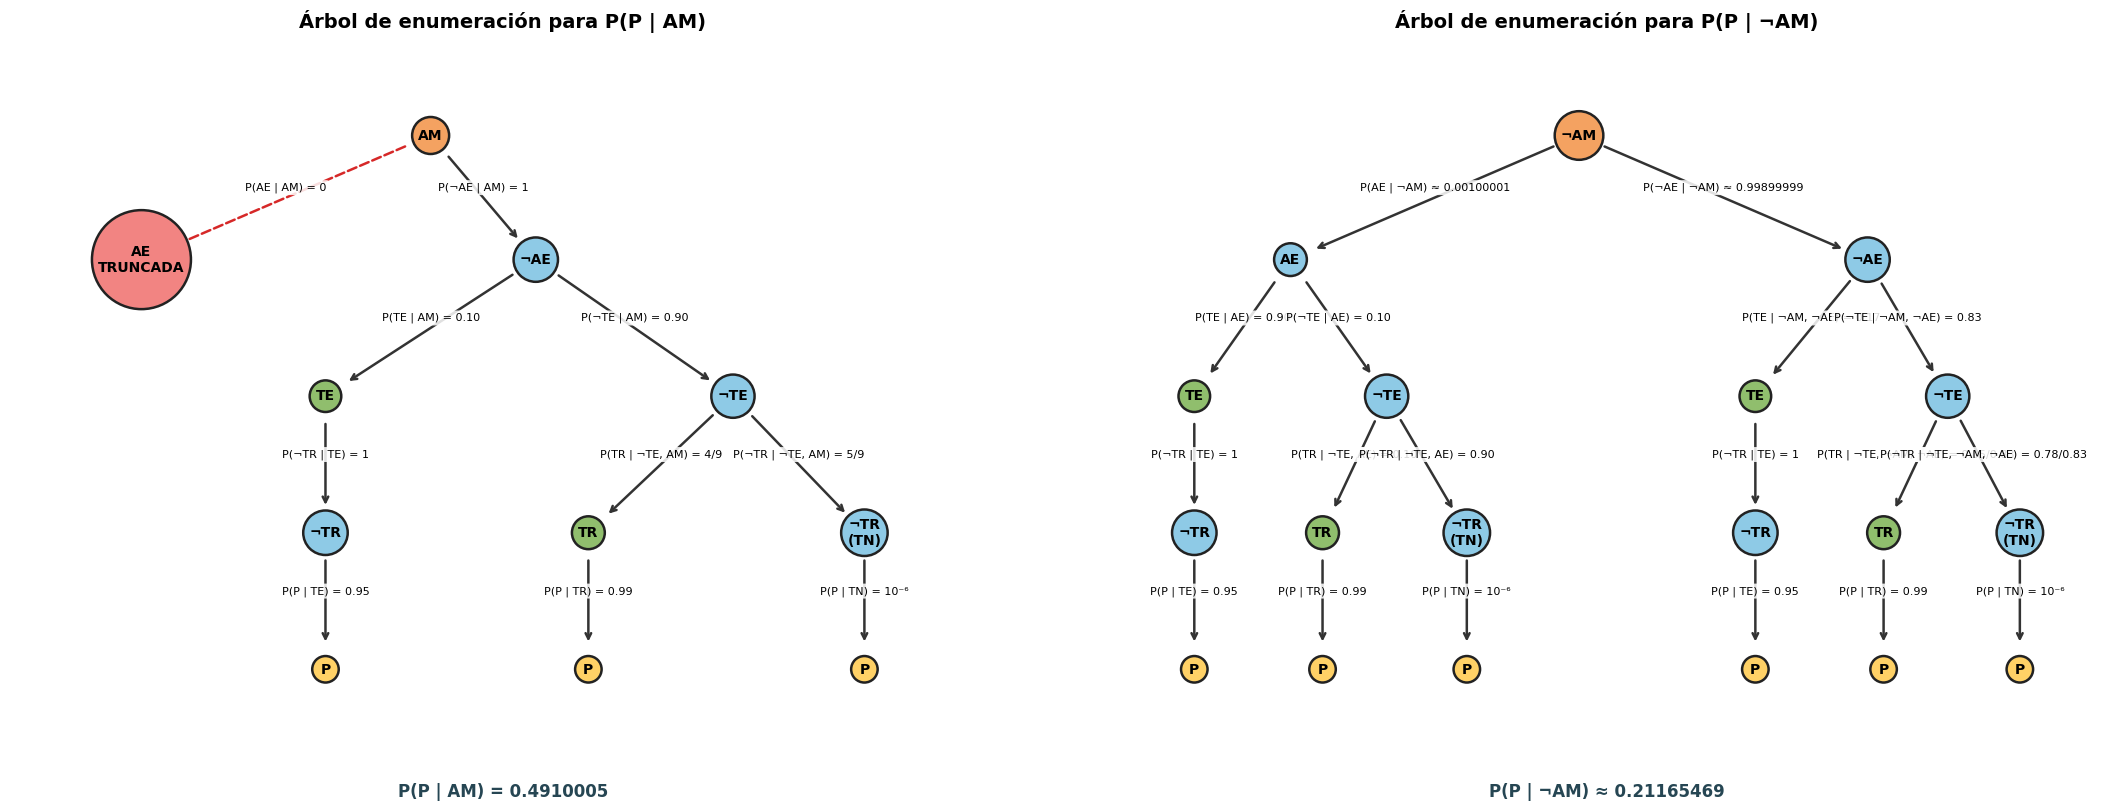

In [35]:
#arboles ej3.1

fig, ejes = plt.subplots(1, 2, figsize=(22, 9))

# =========================================================
# ÁRBOL 1: P(P | AM)
# =========================================================

nodos_am = {
    "AM":       (0.0, 4.8, "AM", "#F4A261"),

    # La rama AE es imposible.
    "AE":       (-2.2, 3.8, "AE\nTRUNCADA", "#F28482"),
    "no_AE":    (0.8, 3.8, "¬AE", "#8ECAE6"),

    "TE":       (-0.8, 2.7, "TE", "#90BE6D"),
    "no_TE":    (2.3, 2.7, "¬TE", "#8ECAE6"),

    # Si TE es verdadera, TR debe ser falsa.
    "no_TR_TE": (-0.8, 1.6, "¬TR", "#8ECAE6"),

    # Si TE es falsa, se evalúa TR.
    "TR":       (1.2, 1.6, "TR", "#90BE6D"),
    "no_TR":    (3.3, 1.6, "¬TR\n(TN)", "#8ECAE6"),

    "P_TE":     (-0.8, 0.5, "P", "#FFD166"),
    "P_TR":     (1.2, 0.5, "P", "#FFD166"),
    "P_TN":     (3.3, 0.5, "P", "#FFD166")
}

conexiones_am = [
    (
        "AM", "AE",
        "P(AE | AM) = 0",
        "--", "#D62828"
    ),
    (
        "AM", "no_AE",
        "P(¬AE | AM) = 1",
        "-", "#333333"
    ),

    (
        "no_AE", "TE",
        "P(TE | AM) = 0.10",
        "-", "#333333"
    ),
    (
        "no_AE", "no_TE",
        "P(¬TE | AM) = 0.90",
        "-", "#333333"
    ),

    (
        "TE", "no_TR_TE",
        "P(¬TR | TE) = 1",
        "-", "#333333"
    ),
    (
        "no_TR_TE", "P_TE",
        "P(P | TE) = 0.95",
        "-", "#333333"
    ),

    (
        "no_TE", "TR",
        "P(TR | ¬TE, AM) = 4/9",
        "-", "#333333"
    ),
    (
        "no_TE", "no_TR",
        "P(¬TR | ¬TE, AM) = 5/9",
        "-", "#333333"
    ),

    (
        "TR", "P_TR",
        "P(P | TR) = 0.99",
        "-", "#333333"
    ),
    (
        "no_TR", "P_TN",
        "P(P | TN) = 10⁻⁶",
        "-", "#333333"
    )
]

dibujar_arbol(
    ejes[0],
    nodos_am,
    conexiones_am,
    "Árbol de enumeración para P(P | AM)",
    "P(P | AM) = 0.4910005"
)


# =========================================================
# ÁRBOL 2: P(P | ¬AM)
# =========================================================

nodos_no_am = {
    "no_AM":       (0.0, 4.8, "¬AM", "#F4A261"),

    "AE":          (-3.6, 3.8, "AE", "#8ECAE6"),
    "no_AE":       (3.6, 3.8, "¬AE", "#8ECAE6"),

    # Ramas correspondientes a AE.
    "TE_AE":       (-4.8, 2.7, "TE", "#90BE6D"),
    "no_TE_AE":    (-2.4, 2.7, "¬TE", "#8ECAE6"),

    "no_TR_TE_AE": (-4.8, 1.6, "¬TR", "#8ECAE6"),
    "TR_AE":       (-3.2, 1.6, "TR", "#90BE6D"),
    "no_TR_AE":    (-1.4, 1.6, "¬TR\n(TN)", "#8ECAE6"),

    "P_TE_AE":     (-4.8, 0.5, "P", "#FFD166"),
    "P_TR_AE":     (-3.2, 0.5, "P", "#FFD166"),
    "P_TN_AE":     (-1.4, 0.5, "P", "#FFD166"),

    # Ramas correspondientes a ausencia de averías.
    "TE_SA":       (2.2, 2.7, "TE", "#90BE6D"),
    "no_TE_SA":    (4.6, 2.7, "¬TE", "#8ECAE6"),

    "no_TR_TE_SA": (2.2, 1.6, "¬TR", "#8ECAE6"),
    "TR_SA":       (3.8, 1.6, "TR", "#90BE6D"),
    "no_TR_SA":    (5.5, 1.6, "¬TR\n(TN)", "#8ECAE6"),

    "P_TE_SA":     (2.2, 0.5, "P", "#FFD166"),
    "P_TR_SA":     (3.8, 0.5, "P", "#FFD166"),
    "P_TN_SA":     (5.5, 0.5, "P", "#FFD166")
}

conexiones_no_am = [
    (
        "no_AM", "AE",
        "P(AE | ¬AM) ≈ 0.00100001",
        "-", "#333333"
    ),
    (
        "no_AM", "no_AE",
        "P(¬AE | ¬AM) ≈ 0.99899999",
        "-", "#333333"
    ),

    # -----------------------------------------
    # Rama con avería eléctrica
    # -----------------------------------------

    (
        "AE", "TE_AE",
        "P(TE | AE) = 0.90",
        "-", "#333333"
    ),
    (
        "AE", "no_TE_AE",
        "P(¬TE | AE) = 0.10",
        "-", "#333333"
    ),

    (
        "TE_AE", "no_TR_TE_AE",
        "P(¬TR | TE) = 1",
        "-", "#333333"
    ),
    (
        "no_TR_TE_AE", "P_TE_AE",
        "P(P | TE) = 0.95",
        "-", "#333333"
    ),

    (
        "no_TE_AE", "TR_AE",
        "P(TR | ¬TE, AE) = 0.10",
        "-", "#333333"
    ),
    (
        "no_TE_AE", "no_TR_AE",
        "P(¬TR | ¬TE, AE) = 0.90",
        "-", "#333333"
    ),

    (
        "TR_AE", "P_TR_AE",
        "P(P | TR) = 0.99",
        "-", "#333333"
    ),
    (
        "no_TR_AE", "P_TN_AE",
        "P(P | TN) = 10⁻⁶",
        "-", "#333333"
    ),

    # -----------------------------------------
    # Rama sin averías
    # -----------------------------------------

    (
        "no_AE", "TE_SA",
        "P(TE | ¬AM, ¬AE) = 0.17",
        "-", "#333333"
    ),
    (
        "no_AE", "no_TE_SA",
        "P(¬TE | ¬AM, ¬AE) = 0.83",
        "-", "#333333"
    ),

    (
        "TE_SA", "no_TR_TE_SA",
        "P(¬TR | TE) = 1",
        "-", "#333333"
    ),
    (
        "no_TR_TE_SA", "P_TE_SA",
        "P(P | TE) = 0.95",
        "-", "#333333"
    ),

    (
        "no_TE_SA", "TR_SA",
        "P(TR | ¬TE, ¬AM, ¬AE) = 0.05/0.83",
        "-", "#333333"
    ),
    (
        "no_TE_SA", "no_TR_SA",
        "P(¬TR | ¬TE, ¬AM, ¬AE) = 0.78/0.83",
        "-", "#333333"
    ),

    (
        "TR_SA", "P_TR_SA",
        "P(P | TR) = 0.99",
        "-", "#333333"
    ),
    (
        "no_TR_SA", "P_TN_SA",
        "P(P | TN) = 10⁻⁶",
        "-", "#333333"
    )
]

dibujar_arbol(
    ejes[1],
    nodos_no_am,
    conexiones_no_am,
    "Árbol de enumeración para P(P | ¬AM)",
    "P(P | ¬AM) ≈ 0.21165469"
)

plt.subplots_adjust(
    left=0.03,
    right=0.98,
    top=0.90,
    bottom=0.10,
    wspace=0.12
)

plt.show()

#### 3.2 Probabilidad de avería mecánica dado que el piloto se enciende y la temperatura es elevada

Ahora se observan dos evidencias:

$$
TE=V
$$

$$
P=V
$$

Se desea calcular:

$$
P(AM\mid TE,P)
$$

Aplicando el teorema de Bayes:

$$
P(AM\mid TE,P)
=
\frac{P(TE,P\mid AM)P(AM)}
{P(TE,P)}
$$

Como trabajamos en clase con el profesor, volvemos a separar el cálculo en las ramas $AM$ y $\neg AM$.

En este caso, como $TE$ es una evidencia conocida, todas las ramas correspondientes a $\neg TE$, $TR$ y $TN$ se descartan. Solamente permanecen las ramas compatibles con temperatura elevada y piloto encendido.

---

##### A. Cálculo de $P(TE,P\mid AM)$

Si existe una avería mecánica:

$$
P(AE\mid AM)=0
$$

por lo que la rama $AE$ se trunca.

La probabilidad de observar temperatura elevada y piloto encendido es:

$$
P(TE,P\mid AM)
=
P(TE\mid AM)P(P\mid TE)
$$

$$
P(TE,P\mid AM)
=
0.10(0.95)
$$

$$
\boxed{
P(TE,P\mid AM)=0.095
}
$$

---

##### B. Cálculo de $P(TE,P\mid\neg AM)$

Si no existe una avería mecánica, todavía puede existir una avería eléctrica o no existir ninguna avería.

La probabilidad correspondiente a la rama de avería eléctrica es:

$$
P(TE,P\mid AE)
=
P(TE\mid AE)P(P\mid TE)
$$

$$
P(TE,P\mid AE)
=
0.90(0.95)=0.855
$$

La probabilidad correspondiente a la rama sin averías es:

$$
P(TE,P\mid\neg AM,\neg AE)
=
0.17(0.95)
$$

$$
P(TE,P\mid\neg AM,\neg AE)
=
0.1615
$$

Combinando las dos posibilidades:

$$
\begin{aligned}
P(TE,P\mid\neg AM)
={}&P(AE\mid\neg AM)(0.855)\\
&+P(\neg AE\mid\neg AM)(0.1615)
\end{aligned}
$$

$$
\begin{aligned}
P(TE,P\mid\neg AM)
={}&0.00100001(0.855)\\
&+0.99899999(0.1615)
\end{aligned}
$$

$$
\boxed{
P(TE,P\mid\neg AM)\approx0.16219351
}
$$

---

##### C. Aplicación del teorema de Bayes

La probabilidad buscada es:

$$
P(AM\mid TE,P)
=
\frac{P(TE,P\mid AM)P(AM)}
{P(TE,P\mid AM)P(AM)
+
P(TE,P\mid\neg AM)P(\neg AM)}
$$

Reemplazando:

$$
P(AM\mid TE,P)
=
\frac{0.095(0.00001)}
{0.095(0.00001)+0.16219351(0.99999)}
$$

$$
P(AM\mid TE,P)
=
\frac{0.00000095}
{0.162192835}
$$

$$
P(AM\mid TE,P)
\approx5.85723\times10^{-6}
$$

En porcentaje:

$$
\boxed{
P(AM\mid TE,P)\approx0.000586\%
}
$$

El resultado es menor que el del inciso anterior porque la temperatura elevada no es una evidencia característica de la avería mecánica:

$$
P(TE\mid AM)=0.10
$$

En cambio, es mucho más frecuente cuando existe una avería eléctrica:

$$
P(TE\mid AE)=0.90
$$

Además, una vez que conocemos la temperatura, el piloto no aporta nueva información sobre la causa de esa temperatura. El piloto depende directamente de la temperatura y no directamente del tipo de avería.

Por eso se cumple:

$$
P(AM\mid TE,P)=P(AM\mid TE)
$$

El factor $P(P\mid TE)=0.95$ aparece en todas las ramas compatibles y se cancela durante la normalización.

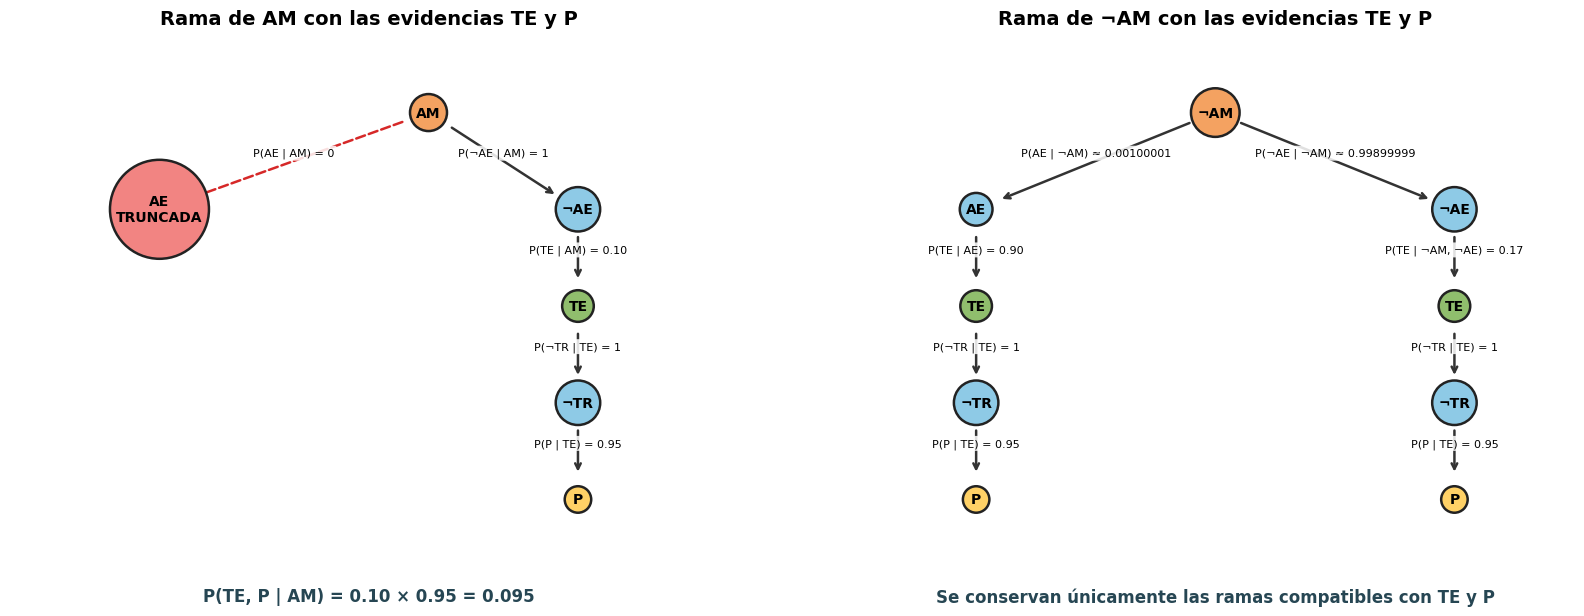

In [36]:
fig, ejes = plt.subplots(1, 2, figsize=(17, 7))

# =========================================================
# ÁRBOL REDUCIDO: P(TE, P | AM)
# =========================================================

nodos_am_te = {
    "AM":    (0, 4, "AM", "#F4A261"),
    "AE":    (-1.8, 3, "AE\nTRUNCADA", "#F28482"),
    "no_AE": (1.0, 3, "¬AE", "#8ECAE6"),
    "TE":    (1.0, 2, "TE", "#90BE6D"),
    "no_TR": (1.0, 1, "¬TR", "#8ECAE6"),
    "P":     (1.0, 0, "P", "#FFD166")
}

conexiones_am_te = [
    ("AM", "AE", "P(AE | AM) = 0", "--", "#D62828"),
    ("AM", "no_AE", "P(¬AE | AM) = 1", "-", "#333333"),
    ("no_AE", "TE", "P(TE | AM) = 0.10", "-", "#333333"),
    ("TE", "no_TR", "P(¬TR | TE) = 1", "-", "#333333"),
    ("no_TR", "P", "P(P | TE) = 0.95", "-", "#333333")
]

dibujar_arbol(
    ejes[0],
    nodos_am_te,
    conexiones_am_te,
    "Rama de AM con las evidencias TE y P",
    "P(TE, P | AM) = 0.10 × 0.95 = 0.095"
)


# =========================================================
# ÁRBOL REDUCIDO: P(TE, P | ¬AM)
# =========================================================

nodos_no_am_te = {
    "no_AM":    (0, 4, "¬AM", "#F4A261"),

    "AE":       (-2, 3, "AE", "#8ECAE6"),
    "no_AE":    (2, 3, "¬AE", "#8ECAE6"),

    "TE_AE":    (-2, 2, "TE", "#90BE6D"),
    "TE_SA":    (2, 2, "TE", "#90BE6D"),

    "no_TR_AE": (-2, 1, "¬TR", "#8ECAE6"),
    "no_TR_SA": (2, 1, "¬TR", "#8ECAE6"),

    "P_AE":     (-2, 0, "P", "#FFD166"),
    "P_SA":     (2, 0, "P", "#FFD166")
}

conexiones_no_am_te = [
    (
        "no_AM", "AE",
        "P(AE | ¬AM) ≈ 0.00100001",
        "-", "#333333"
    ),
    (
        "no_AM", "no_AE",
        "P(¬AE | ¬AM) ≈ 0.99899999",
        "-", "#333333"
    ),

    (
        "AE", "TE_AE",
        "P(TE | AE) = 0.90",
        "-", "#333333"
    ),
    (
        "TE_AE", "no_TR_AE",
        "P(¬TR | TE) = 1",
        "-", "#333333"
    ),
    (
        "no_TR_AE", "P_AE",
        "P(P | TE) = 0.95",
        "-", "#333333"
    ),

    (
        "no_AE", "TE_SA",
        "P(TE | ¬AM, ¬AE) = 0.17",
        "-", "#333333"
    ),
    (
        "TE_SA", "no_TR_SA",
        "P(¬TR | TE) = 1",
        "-", "#333333"
    ),
    (
        "no_TR_SA", "P_SA",
        "P(P | TE) = 0.95",
        "-", "#333333"
    )
]

dibujar_arbol(
    ejes[1],
    nodos_no_am_te,
    conexiones_no_am_te,
    "Rama de ¬AM con las evidencias TE y P",
    "Se conservan únicamente las ramas compatibles con TE y P"
)

plt.subplots_adjust(
    left=0.05,
    right=0.97,
    top=0.88,
    bottom=0.12,
    wspace=0.18
)

plt.show()

4. Cada día se procesa un producto en secuencia en dos máquinas, M1 y M2. Una inspección se realiza después de que una unidad del producto se completa en cualquiera de las máquinas. 
<br><br>Hay un 5% de probabilidades de que una unidad sea desechada antes de inspeccionarla. Después de la inspección, hay un 3% de probabilidades de que la unidad sea desechada y un 7% de probabilidades de ser devuelta a la misma máquina para trabajarla
de nuevo. Si una unidad pasa la inspección en ambas máquinas es
buena.

        4.1 Dibuje la cadena de Markov que representa este problema y describa para cada estado si es transitorio, recurrente, o absorbente.

        4.2 Arme la matriz de transición

        4.3 Calcule la probabilidad de que una pieza que inicia el proceso en la máquina M1 sea desechada.

        4.4 Calcule la probabilidad de que una pieza de la máquina M2 sea terminada.

        4.5 Si los tiempos de procesamiento en las máquinas M1 y M2 son respectivamente de 20 y 30 minutos y los tiempos de inspección son respectivamente de 5 y 7 minutos, ¿cuánto tiempo tarda en ser procesada una pieza que inicia en la máquina M1?

## 4.1 — Diagrama y clasificación de los estados

**Estados:** M1, I1, M2, I2, D (Desechada), B (Buena)

**Transiciones (según el diagrama):**
* M1 → I1 (0,95) ; M1 → D (0,05)
* I1 → M2 (0,90) ; I1 → M1 (0,07) ; I1 → D (0,03)
* M2 → I2 (0,95) ; M2 → D (0,05)
* I2 → B (0,90) ; I2 → M2 (0,07) ; I2 → D (0,03)
* D → D (1,00)
* B → B (1,00)

**Clasificación de los estados:**

| Estado | Clasificación | Justificación |
| :--- | :--- | :--- |
| **M1** | Transitorio | Se puede reingresar desde I1 (0,07), pero con el tiempo el proceso lo abandona definitivamente (probabilidad de nunca regresar tiende a 1). |
| **I1** | Transitorio | Se sale hacia M2 o D; no hay retorno garantizado infinito. |
| **M2** | Transitorio | Alimentado por I1 y por el retrabajo desde I2; eventualmente se abandona. |
| **I2** | Transitorio | Se sale hacia B o D. |
| **D** (Desechada) | Absorbente | No sale ninguna flecha (P=1 de permanecer). Caso particular de estado recurrente sin salida. |
| **B** (Buena) | Absorbente | Mismo argumento: autotransición con probabilidad 1, sin salidas. |

> *Nota: No existen estados "recurrentes no absorbentes" en este modelo: los únicos recurrentes son D y B, y ambos son además absorbentes.*

## 4.2 — Matriz de transición

Orden de estados: M1, I1, M2, I2, D, B

$$
P = \begin{pmatrix}
0 & 0,95 & 0 & 0 & 0,05 & 0 \\
0,07 & 0 & 0,90 & 0 & 0,03 & 0 \\
0 & 0 & 0 & 0,95 & 0,05 & 0 \\
0 & 0 & 0,07 & 0 & 0,03 & 0,90 \\
0 & 0 & 0 & 0 & 1 & 0 \\
0 & 0 & 0 & 0 & 0 & 1
\end{pmatrix}
$$

**Forma canónica**
$$
P = \begin{pmatrix} Q & R \\ 0 & I \end{pmatrix}
$$

$$
Q = \begin{pmatrix}
0 & 0,95 & 0 & 0 \\
0,07 & 0 & 0,90 & 0 \\
0 & 0 & 0 & 0,95 \\
0 & 0 & 0,07 & 0
\end{pmatrix}
\qquad
R = \begin{pmatrix}
0,05 & 0 \\
0,03 & 0 \\
0,05 & 0 \\
0,03 & 0,90
\end{pmatrix}
$$
*(Filas de Q y R: M1, I1, M2, I2 — Columnas de Q: M1, I1, M2, I2 — Columnas de R: D, B)*

**Matriz fundamental $N = (I - Q)^{-1}$**

$$
I - Q = \begin{pmatrix}
1 & -0,95 & 0 & 0 \\
-0,07 & 1 & -0,90 & 0 \\
0 & 0 & 1 & -0,95 \\
0 & 0 & -0,07 & 1
\end{pmatrix}
$$

Resolviendo el sistema:
$$
N = \begin{pmatrix}
1,0712 & 1,0177 & 0,9812 & 0,9321 \\
0,0750 & 1,0712 & 1,0328 & 0,9812 \\
0 & 0 & 1,0712 & 1,0177 \\
0 & 0 & 0,0750 & 1,0712
\end{pmatrix}
$$
*(Filas y columnas en orden M1, I1, M2, I2). Cada elemento $N_{ij}$ es el número esperado de veces que se visita el estado $j$ habiendo comenzado en el estado $i$.*

## 4.3 — Probabilidad de que una pieza que inicia en M1 sea desechada

Calculamos $B = N \cdot R$ (probabilidades de absorción):
$$
B_{M1,D} = N_{M1,M1}(0,05) + N_{M1,I1}(0,03) + N_{M1,M2}(0,05) + N_{M1,I2}(0,03)
$$
$$
B_{M1,D} = 1,0712(0,05) + 1,0177(0,03) + 0,9812(0,05) + 0,9321(0,03) = 0,1611
$$

**P(desechada | inicia en M1) ≈ 0,1611 = 16,11 %**

* **Control:** $B_{M1,B} = 0,9321 \times 0,90 = 0,8389$ ; y $0,1611 + 0,8389 = 1$ ✓
* **Verificación por recursión (atajo):** Cada etapa (máquina + inspección) tiene la misma estructura numérica, por lo que la probabilidad de "superar" una etapa es $p = 0,855 / 0,9335 = 0,9159$. Como una pieza que inicia en M1 debe superar dos etapas en cadena: $P(\text{buena}) = p^2 = 0,8389 \rightarrow P(\text{desechada}) = 1 - 0,8389 = 0,1611$ ✔️

## 4.4 — Probabilidad de que una pieza que llega a M2 sea terminada (buena)

Tomamos la fila M2, columna B de $B = N \cdot R$. Solo I2 tiene salida hacia B (0,90):
$$
B_{M2,B} = N_{M2,I2} \times 0,90 = 1,0177 \times 0,90 = 0,9159
$$

**P(terminada/buena | llega a M2) ≈ 0,9159 = 91,59 %**

* **Control:** $B_{M2,D} = N_{M2,M2}(0,05) + N_{M2,I2}(0,03) = 1,0712(0,05) + 1,0177(0,03) = 0,0841$; y $0,9159 + 0,0841 = 1$ ✓
* Este valor coincide exactamente con el $p=0,9159$ usado como atajo en el 4.3: es la probabilidad de superar una sola etapa (máquina + inspección).

## 4.5 — Tiempo esperado de proceso para una pieza que inicia en M1

Tiempos por estado (minutos), orden M1, I1, M2, I2:
$$
\tau = \begin{pmatrix} 20 \\ 5 \\ 30 \\ 7 \end{pmatrix}
$$

Calculamos $T = N \cdot \tau$, fila M1:
$$
T_{M1} = N_{M1,M1}(20) + N_{M1,I1}(5) + N_{M1,M2}(30) + N_{M1,I2}(7)
$$
$$
T_{M1} = 1,0712(20) + 1,0177(5) + 0,9812(30) + 0,9321(7)
$$
$$
T_{M1} = 21,424 + 5,089 + 29,436 + 6,525 = 62,47
$$

**Tiempo esperado ≈ 62,47 minutos**

* **Verificación por ecuaciones recursivas de tiempo esperado:**
$$
T_{M2} = 30 + 0,95 \cdot T_{I2} \qquad T_{I2} = 7 + 0,07 \cdot T_{M2}
$$
Resolviendo: $T_{M2} = 39,26 \text{ min} ; T_{I2} = 9,75 \text{ min}$

$$
T_{I1} = 5 + 0,07 \cdot T_{M1} + 0,90 \cdot T_{M2} \qquad T_{M1} = 20 + 0,95 \cdot T_{I1}
$$
Resolviendo: $T_{M1} = 62,47 \text{ minutos}$ ✔️ (coincide con el cálculo matricial)

## Resumen final

| Ítem | Resultado |
| :--- | :--- |
| **4.3 — P(desechada \| inicia en M1)** | 16,11 % |
| **4.4 — P(buena \| llega a M2)** | 91,59 % |
| **4.5 — Tiempo esperado desde M1** | 62,47 minutos |

## Ejercicios de implementación

> Recuerde adjuntar en la presentación el prompt inicial que ha utilizado para cada ejercicio de implementación y si considera que le dio la información completa para resolver el ejercicio o qué cambios adicionales tuvo que pedir de manera iterativa.

5. Diseñar un controlador difuso para jugar al Pong. El juego consiste en una pelota que rebota dentro de una cancha rectangular y palas controladas por el sistema difuso o el jugador. El entorno debe cumplir las siguientes reglas:

* La cancha posee dimensiones fijas.
* La pelota rebota en los bordes superior e inferior. Los bordes laterales funcionan como un arco y cuando la pelota atraviesa un borde suma un punto al lado opuesto, sin importar quién toca la pelota por última vez.
* La velocidad de la pelota debe ir incrementando con cada rebot en una pala o pared. Marcar un gol restablece los valores de velocidad a su configuración original.
* Cada pala únicamente puede desplazarse verticalmente y con velocidad fija durante toda la ejecución.
* Cada pala tiene una altura fija.
* Es necesario definir un puntaje mínimo que de el juego por finalizado.

La variable de salida sobre la que actúa el controlador es la **velocidad de la pala**. Las variables de entrada quedan a definir por ustedes.

Como mínimo deben hacer un modo de "un jugador" (ustedes vs. el agente), pero pueden incorporar un modo de "dos jugadores" que consista en utilizar dos agentes con variaciones en las reglas del motor de inferencia, mecanismos de fuzzificación o desfuzzificación de la información y/o las funciones de pertenencia de cada grupo.

Aquí tienes el texto corregido para tu informe, reflejando fielmente la última actualización que implementó las velocidades progresivas (lenta, media y rápida).

---

## 5. Pong con controlador difuso

Se desarrolló un juego de Pong en modo de un jugador utilizando `pygame`.

* La pala azul de la izquierda es controlada por el jugador mediante las teclas **W/S** o las flechas **arriba/abajo**.
* La pala roja de la derecha es controlada por un agente difuso.
* La cancha tiene dimensiones fijas de $900 \times 600$ píxeles.
* Antes de comenzar se puede elegir un objetivo de entre **1 y 15 goles**.
* El valor predeterminado es de 5 goles.
* La partida termina cuando el jugador o el agente alcanza el objetivo seleccionado.

### Funcionamiento general del juego

La pelota rebota contra los bordes superior e inferior y contra las dos palas. Cada vez que ocurre uno de estos rebotes, su velocidad aumenta un 3 %:

$$\vec{v}_{nueva}=1{,}03\cdot\vec{v}_{anterior}$$

Los bordes laterales funcionan como arcos. Si la pelota atraviesa uno de ellos, el punto se asigna al lado contrario. Después de cada gol, la pelota vuelve al centro y recupera su velocidad inicial:

$$v_{x0}=5\ \text{px/fotograma}$$

$$v_{y0}=3{,}5\ \text{px/fotograma}$$

Los signos de ambas componentes se seleccionan aleatoriamente para modificar la dirección inicial.

Las clases `Pala` y `Pelota` separan las responsabilidades principales del juego. La clase `Pala` administra el movimiento vertical y los límites de cada pala, mientras que la clase `Pelota` administra su posición, velocidad, colisiones, aceleración y detección de goles.

El programa utiliza tres estados:

* `MENU`: muestra las reglas y permite seleccionar la cantidad de goles.
* `JUGANDO`: ejecuta la partida.
* `FIN`: muestra el ganador y el resultado final.

### Estrategia del agente

El agente utiliza la dirección horizontal de la pelota para decidir qué posición debe tomar como objetivo.

Si la pelota se mueve hacia la derecha, se está acercando al agente y el objetivo es su posición vertical:

$$y_{\text{objetivo}}=y_{\text{pelota}}$$

Si la pelota se mueve hacia la izquierda, se está alejando del agente. En ese caso, la pala intenta regresar al centro de la cancha para prepararse para el siguiente ataque:

$$y_{\text{objetivo}}=\frac{\text{alto de la cancha}}{2}$$

A continuación, se calcula el error vertical entre el objetivo y el centro de la pala:

$$e=y_{\text{objetivo}}-y_{\text{pala}}$$

Por lo tanto:

* Si $e<0$, el objetivo está arriba de la pala.
* Si $e\approx0$, la pala está alineada con el objetivo.
* Si $e>0$, el objetivo está abajo de la pala.

### Fuzzificación del error

El error se divide por un rango de referencia de 80 píxeles y se limita al intervalo $[-1,1]$:

$$e_n=\operatorname{clip}\left(\frac{e}{80},-1,1\right)$$

Sobre el error normalizado se definen tres funciones de pertenencia lineales:

$$\mu_{\text{arriba}}=\max(0,-e_n)$$

$$\mu_{\text{centrada}}=\max(0,1-\vert{}e_n\vert{})$$

$$\mu_{\text{abajo}}=\max(0,e_n)$$

Estas funciones permiten que un mismo error pueda pertenecer parcialmente a más de un conjunto. Por ejemplo, el objetivo puede encontrarse parcialmente centrado y parcialmente abajo.

### Base de reglas

El controlador utiliza tres reglas sencillas:

| Condición | Acción |
| --- | --- |
| Si el objetivo está arriba | Subir |
| Si el objetivo está centrado | Detenerse |
| Si el objetivo está abajo | Bajar |

Se utiliza un modelo **Sugeno de orden cero** con los siguientes consecuentes:

$$\text{subir}=-1,\qquad \text{detenerse}=0,\qquad \text{bajar}=1$$

La salida se obtiene mediante el promedio ponderado:

$$u= \frac{ -\mu_{\text{arriba}}+\mu_{\text{abajo}} }{ \mu_{\text{arriba}}+ \mu_{\text{centrada}}+ \mu_{\text{abajo}} }$$

Finalmente, para dotar al agente de un movimiento más orgánico, la salida del controlador no evalúa únicamente la dirección, sino la magnitud del movimiento. Se define la magnitud $m = \vert{}u\vert{}$ y la dirección $d = \operatorname{sgn}(u)$ (donde $-1$ es subir y $1$ es bajar), y se clasifica la salida en tres niveles de velocidad:

| Magnitud del error ($m$) | Intensidad de respuesta | Velocidad asignada |
| --- | --- | --- |
| $m < 0{,}15$ | Detenerse | $0$ px/fotograma |
| $0{,}15 \leq m < 0{,}40$ | Lenta | $3 \cdot d$ px/fotograma |
| $0{,}40 \leq m < 0{,}75$ | Media | $6 \cdot d$ px/fotograma |
| $m \geq 0{,}75$ | Rápida | $9 \cdot d$ px/fotograma |

De esta manera, la lógica difusa determina tanto la dirección como la rapidez con la que se desplaza la pala. Esto permite que el agente se mueva rápidamente cuando la pelota está lejos, y experimente una desaceleración suave y progresiva a medida que se alinea con su objetivo.

In [ ]:
pip install pygame 

     ---------------------------------------- 36.6/36.6 MB 4.0 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [49]:
import random
import pygame

# =============================================================================
# CONFIGURACIÓN
# =============================================================================
ANCHO, ALTO = 900, 600
FPS = 60

ANCHO_PALA, ALTO_PALA = 16, 110

# Diferentes niveles de velocidad (reemplaza la velocidad fija única)
VELOCIDAD_LENTA = 3
VELOCIDAD_MEDIA = 6
VELOCIDAD_RAPIDA = 9

TAMANO_PELOTA = 16
VELOCIDAD_X_INICIAL = 5.0
VELOCIDAD_Y_INICIAL = 3.5
FACTOR_ACELERACION = 1.03

GOLES_INICIALES = 5
MIN_GOLES, MAX_GOLES = 1, 15

# Parámetros del controlador difuso.
RANGO_ERROR = 80.0
UMBRAL_MOVIMIENTO = 0.15

# Colores.
FONDO = (18, 24, 38)
PANEL = (27, 35, 52)
BLANCO = (240, 240, 240)
GRIS = (150, 160, 175)
AZUL = (52, 152, 219)
ROJO = (231, 76, 60)
AMARILLO = (241, 196, 15)
CELESTE = (100, 200, 255)


# =============================================================================
# CONTROLADOR DIFUSO
# =============================================================================
def limitar(valor, minimo, maximo):
    """Mantiene un valor dentro de un intervalo."""
    return max(minimo, min(valor, maximo))


def fuzzificar_error(error_vertical):
    """Calcula las pertenencias: arriba, centrada y abajo."""
    error = limitar(error_vertical / RANGO_ERROR, -1.0, 1.0)

    arriba = max(0.0, -error)
    centrada = max(0.0, 1.0 - abs(error))
    abajo = max(0.0, error)

    return arriba, centrada, abajo


def controlador_difuso(error_vertical):
    """Decide si la pala debe subir, detenerse o bajar, y a qué velocidad."""
    arriba, centrada, abajo = fuzzificar_error(error_vertical)

    # Sugeno de orden cero: el comando va de -1.0 a 1.0
    comando = (-arriba + abajo) / (arriba + centrada + abajo)
    
    # Extraemos qué tan fuerte es el movimiento (magnitud) y hacia dónde (dirección)
    magnitud = abs(comando)
    direccion = -1 if comando < 0 else 1

    # Asignamos la velocidad según el grado de error
    if magnitud < UMBRAL_MOVIMIENTO:
        return 0
    elif magnitud < 0.4:
        return VELOCIDAD_LENTA * direccion
    elif magnitud < 0.75:
        return VELOCIDAD_MEDIA * direccion
    else:
        return VELOCIDAD_RAPIDA * direccion


# =============================================================================
# ELEMENTOS DEL JUEGO
# =============================================================================
class Pala:
    def __init__(self, x, color):
        self.rect = pygame.Rect(x, 0, ANCHO_PALA, ALTO_PALA)
        self.color = color
        self.reiniciar()

    def reiniciar(self):
        self.rect.centery = ALTO // 2

    def mover(self, velocidad):
        self.rect.y += velocidad
        self.rect.y = limitar(self.rect.y, 0, ALTO - ALTO_PALA)

    def dibujar(self, pantalla):
        pygame.draw.rect(pantalla, self.color, self.rect)


class Pelota:
    def __init__(self):
        self.rect = pygame.Rect(0, 0, TAMANO_PELOTA, TAMANO_PELOTA)
        self.posicion = pygame.Vector2()
        self.velocidad = pygame.Vector2()
        self.reiniciar()

    def reiniciar(self):
        """Centra la pelota y restaura su velocidad inicial."""
        self.rect.center = (ANCHO // 2, ALTO // 2)
        self.posicion.update(self.rect.x, self.rect.y)
        self.velocidad.update(
            random.choice((-1, 1)) * VELOCIDAD_X_INICIAL,
            random.choice((-1, 1)) * VELOCIDAD_Y_INICIAL,
        )

    def acelerar(self):
        """Aumenta la velocidad después de cada rebote."""
        self.velocidad *= FACTOR_ACELERACION

    def actualizar(self, jugador, agente):
        """Actualiza la pelota y devuelve el nombre del goleador o None."""
        self.posicion += self.velocidad
        self.rect.topleft = round(self.posicion.x), round(self.posicion.y)

        # Rebotes contra techo y piso.
        if self.rect.top <= 0 and self.velocidad.y < 0:
            self.rect.top = 0
            self.posicion.y = self.rect.y
            self.velocidad.y = abs(self.velocidad.y)
            self.acelerar()
        elif self.rect.bottom >= ALTO and self.velocidad.y > 0:
            self.rect.bottom = ALTO
            self.posicion.y = self.rect.y
            self.velocidad.y = -abs(self.velocidad.y)
            self.acelerar()

        # Rebotes contra las palas.
        if self.rect.colliderect(jugador.rect) and self.velocidad.x < 0:
            self.rect.left = jugador.rect.right
            self.posicion.x = self.rect.x
            self.velocidad.x = abs(self.velocidad.x)
            self.acelerar()
        elif self.rect.colliderect(agente.rect) and self.velocidad.x > 0:
            self.rect.right = agente.rect.left
            self.posicion.x = self.rect.x
            self.velocidad.x = -abs(self.velocidad.x)
            self.acelerar()

        # Los laterales funcionan como arcos.
        if self.rect.right < 0:
            return "agente"
        if self.rect.left > ANCHO:
            return "jugador"
        return None

    def dibujar(self, pantalla):
        pygame.draw.ellipse(pantalla, AMARILLO, self.rect)


# =============================================================================
# INTERFAZ
# =============================================================================
def dibujar_texto(pantalla, fuente, contenido, y, color=BLANCO):
    """Dibuja texto centrado horizontalmente."""
    superficie = fuente.render(contenido, True, color)
    rectangulo = superficie.get_rect(center=(ANCHO // 2, y))
    pantalla.blit(superficie, rectangulo)


def dibujar_menu(pantalla, fuentes, goles_objetivo):
    """Muestra las reglas y permite elegir la cantidad de goles."""
    pantalla.fill(FONDO)
    dibujar_texto(pantalla, fuentes[72], "PONG DIFUSO", 55, CELESTE)

    panel = pygame.Rect(85, 100, ANCHO - 170, 335)
    pygame.draw.rect(pantalla, PANEL, panel, border_radius=14)
    pygame.draw.rect(pantalla, GRIS, panel, width=2, border_radius=14)

    dibujar_texto(pantalla, fuentes[36], "REGLAS DEL JUEGO", 135)

    reglas = [
        "1. Controlas la pala azul con W/S o las flechas.",
        "2. La pala roja es controlada por el agente difuso.",
        "3. La pelota acelera al rebotar en una pared o una pala.",
        "4. Si la pelota cruza un lateral, el rival suma un gol.",
    ]
    for indice, regla in enumerate(reglas):
        posicion_y = 185 + indice * 40
        dibujar_texto(pantalla, fuentes[26], regla, posicion_y)

    dibujar_texto(pantalla, fuentes[28], "OBJETIVO DE LA PARTIDA", 360, GRIS)
    dibujar_texto(
        pantalla,
        fuentes[42],
        f"PRIMERO EN LLEGAR A {goles_objetivo} GOLES",
        405,
        AMARILLO,
    )
    dibujar_texto(
        pantalla,
        fuentes[26],
        f"Flechas izquierda/derecha: elegir entre {MIN_GOLES} y {MAX_GOLES}",
        475,
        GRIS,
    )
    dibujar_texto(
        pantalla, fuentes[32], "ESPACIO o ENTER: comenzar", 520, CELESTE
    )
    dibujar_texto(pantalla, fuentes[24], "ESC: salir", 560, GRIS)


def dibujar_juego(
    pantalla,
    fuentes,
    jugador,
    agente,
    pelota,
    puntos_jugador,
    puntos_agente,
    goles_objetivo,
):
    pantalla.fill(FONDO)

    for y in range(0, ALTO, 30):
        pygame.draw.rect(pantalla, GRIS, (ANCHO // 2 - 2, y, 4, 18))

    jugador.dibujar(pantalla)
    agente.dibujar(pantalla)
    pelota.dibujar(pantalla)

    dibujar_texto(
        pantalla, fuentes[48], f"{puntos_jugador}     {puntos_agente}", 40
    )
    dibujar_texto(
        pantalla,
        fuentes[22],
        f"Primero en llegar a {goles_objetivo} goles | ESC: menu",
        ALTO - 20,
        GRIS,
    )


def reiniciar_partida(jugador, agente, pelota):
    jugador.reiniciar()
    agente.reiniciar()
    pelota.reiniciar()
    return 0, 0


# =============================================================================
# PROGRAMA PRINCIPAL
# =============================================================================
def main():
    pygame.init()
    pantalla = pygame.display.set_mode((ANCHO, ALTO))
    pygame.display.set_caption("Pong con controlador difuso")
    reloj = pygame.time.Clock()

    # Las fuentes se crean una sola vez.
    fuentes = {
        tamano: pygame.font.Font(None, tamano)
        for tamano in (22, 24, 26, 28, 32, 36, 42, 48, 54, 72)
    }

    jugador = Pala(35, AZUL)
    agente = Pala(ANCHO - 35 - ANCHO_PALA, ROJO)
    pelota = Pelota()

    goles_objetivo = GOLES_INICIALES
    puntos_jugador = puntos_agente = 0
    ganador = ""
    estado = "MENU"
    ejecutando = True

    while ejecutando:
        # Eventos de teclado y cierre de ventana.
        for evento in pygame.event.get():
            if evento.type == pygame.QUIT:
                ejecutando = False

            elif evento.type == pygame.KEYDOWN:
                if estado == "MENU":
                    if evento.key == pygame.K_ESCAPE:
                        ejecutando = False
                    elif evento.key in (pygame.K_LEFT, pygame.K_a):
                        goles_objetivo = limitar(
                            goles_objetivo - 1, MIN_GOLES, MAX_GOLES
                        )
                    elif evento.key in (pygame.K_RIGHT, pygame.K_d):
                        goles_objetivo = limitar(
                            goles_objetivo + 1, MIN_GOLES, MAX_GOLES
                        )
                    elif evento.key in (pygame.K_SPACE, pygame.K_RETURN):
                        puntos_jugador, puntos_agente = reiniciar_partida(
                            jugador, agente, pelota
                        )
                        estado = "JUGANDO"

                elif estado == "JUGANDO" and evento.key == pygame.K_ESCAPE:
                    estado = "MENU"

                elif estado == "FIN":
                    if evento.key == pygame.K_SPACE:
                        puntos_jugador, puntos_agente = reiniciar_partida(
                            jugador, agente, pelota
                        )
                        estado = "JUGANDO"
                    elif evento.key == pygame.K_m:
                        estado = "MENU"
                    elif evento.key == pygame.K_ESCAPE:
                        ejecutando = False

        if estado == "MENU":
            dibujar_menu(pantalla, fuentes, goles_objetivo)

        elif estado == "JUGANDO":
            # Pala humana: siempre se mueve a la velocidad máxima (rápida).
            teclas = pygame.key.get_pressed()
            bajar = teclas[pygame.K_s] or teclas[pygame.K_DOWN]
            subir = teclas[pygame.K_w] or teclas[pygame.K_UP]
            jugador.mover((int(bajar) - int(subir)) * VELOCIDAD_RAPIDA)

            # El agente sigue la pelota cuando se acerca.
            # Cuando se aleja, vuelve al centro para prepararse.
            objetivo_y = (
                pelota.rect.centery
                if pelota.velocidad.x > 0
                else ALTO // 2
            )
            error_vertical = objetivo_y - agente.rect.centery
            agente.mover(controlador_difuso(error_vertical))

            # Actualizamos la pelota y el marcador.
            gol = pelota.actualizar(jugador, agente)
            if gol == "jugador":
                puntos_jugador += 1
            elif gol == "agente":
                puntos_agente += 1

            if gol is not None:
                if puntos_jugador >= goles_objetivo:
                    ganador = "Jugador"
                    estado = "FIN"
                elif puntos_agente >= goles_objetivo:
                    ganador = "Agente difuso"
                    estado = "FIN"
                else:
                    pelota.reiniciar()

            dibujar_juego(
                pantalla,
                fuentes,
                jugador,
                agente,
                pelota,
                puntos_jugador,
                puntos_agente,
                goles_objetivo,
            )

        elif estado == "FIN":
            pantalla.fill(FONDO)
            dibujar_texto(
                pantalla, fuentes[72], "PARTIDA TERMINADA", 155, CELESTE
            )
            dibujar_texto(
                pantalla, fuentes[54], f"Ganador: {ganador}", 245, AMARILLO
            )
            dibujar_texto(
                pantalla,
                fuentes[48],
                f"Resultado final: {puntos_jugador} - {puntos_agente}",
                310,
            )
            dibujar_texto(
                pantalla,
                fuentes[28],
                "ESPACIO: repetir con la misma cantidad de goles",
                410,
            )
            dibujar_texto(
                pantalla,
                fuentes[28],
                "M: volver al menu y cambiar los goles",
                455,
            )
            dibujar_texto(pantalla, fuentes[24], "ESC: salir", 510, GRIS)

        pygame.display.flip()
        reloj.tick(FPS)

    pygame.quit()


if __name__ == "__main__":
    main()

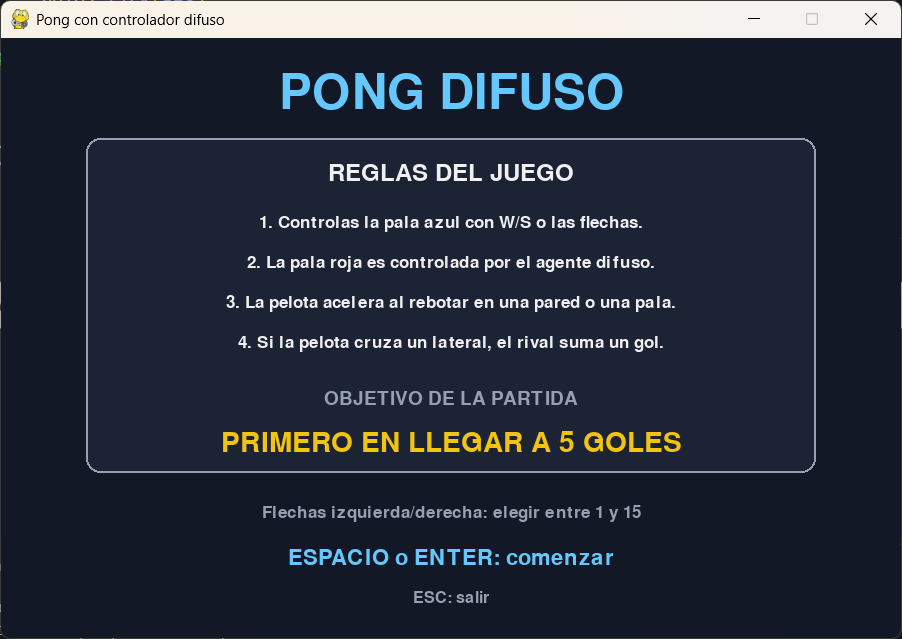

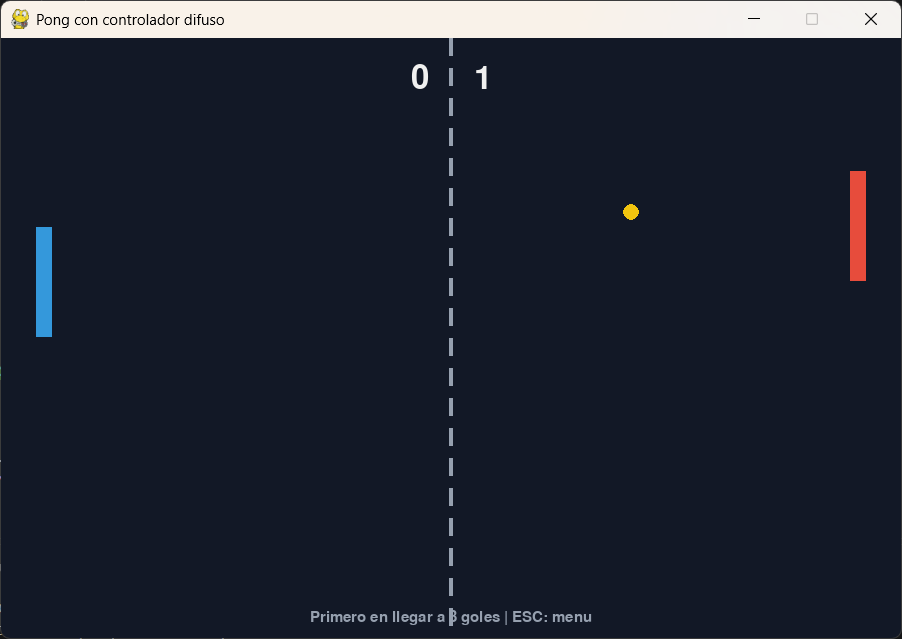

## Prompt inicial y ajustes realizados

### Prompt inicial utilizado

> Actúa como un Ingeniero en Control y Sistemas Inteligentes. Necesito implementar el ejercicio del juego Pong controlado por Lógica Difusa en Python utilizando Pygame.
>
> **Requisitos clave de estilo y arquitectura:**
>
> 1. Simplicidad: Mantén la solución lo más directa y minimalista posible. Evita sobre-ingeniería, clases innecesarias o lógica matemática excesivamente compleja.
> 2. Buenas prácticas de programación: Código limpio (PEP 8), nombres de variables descriptivos, funciones con responsabilidades claras y modularidad.
> 3. Código altamente comentado: Explica detalladamente en comentarios qué hace cada bloque, especialmente la configuración de los conjuntos difusos, el universo de discurso y el ciclo principal del juego.
>
> **Requisitos del juego (Pong):**
>
> - Cancha rectangular con dimensiones fijas (ej. 800x600 px).
> - Pelota con rebote en bordes superior e inferior. Rebote en bordes izquierdo/derecho suma punto al rival y reinicia la pelota al centro.
> - La velocidad de la pelota aumenta gradualmente con cada rebote (en pala o pared) y se reinicia al marcar un gol.
> - Palas con altura fija y movimiento únicamente vertical.
> - Condición de victoria con puntaje límite (ej. el primero en llegar a 5 puntos gana y finaliza la partida).
> - Modo de juego principal: Jugador Humano (teclas W/S o Flechas Arriba/Abajo) vs. Agente Difuso.
>
> **Diseño del Controlador Difuso (Mamdani con scikit-fuzzy):**
>
> - Variables de entrada:
>   1. `error_y`: diferencia entre la posición vertical de la pelota y el centro de la pala.
>   2. `pelota_acercandose`: variable que indica si la pelota se dirige hacia el agente o se aleja.
> - Variable de salida:
>   - `velocidad_pala`: valor desfuzzificado que determina la dirección e intensidad del movimiento vertical. Si la velocidad debe ser fija, la salida debe mapearse a las acciones subir, detenerse o bajar.
> - Funciones de pertenencia triangulares simples.
> - Base reducida de reglas IF-THEN.

### Evaluación del prompt

El prompt inicial fue suficientemente completo para obtener una primera implementación, ya que especificó las reglas del juego, las variables del controlador, el método de inferencia propuesto y las condiciones generales de programación.
Sin embargo, después de analizar y probar la primera solución se realizaron algunos cambios. El prompt fue adecuado como punto de partida, pero la solución final no utiliza literalmente todas sus decisiones iniciales. Los cambios se realizaron para obtener un programa más sencillo, reducir las dependencias externas y cumplir con mayor precisión las restricciones del ejercicio.

# Bibliografía

[Russell, S. & Norvig, P. (2004) _Inteligencia Artificial: Un Enfoque Moderno_. Pearson Educación S.A. (2a Ed.) Madrid, España](https://www.academia.edu/8241613/Inteligencia_Aritificial_Un_Enfoque_Moderno_2da_Edici%C3%B3n_Stuart_J_Russell_y_Peter_Norvig)

[Poole, D. & Mackworth, A. (2023) _Artificial Intelligence: Foundations of Computational Agents_. Cambridge University Press (3a Ed.) Vancouver, Canada](https://artint.info/3e/html/ArtInt3e.html)
